In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn')
%matplotlib inline

In [2]:
# Load the dataset
data = pd.read_csv('/kaggle/input/teenage-pregnancy-bungoma-county2025/bungoma.csv')  # Replace with your dataset path

# Display first few rows
print("First 5 rows of the dataset:")
print(data.head())

# Check data info
print("\nDataset Info:")
print(data.info())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Basic statistics
print("\nBasic Statistics:")
print(data.describe())

First 5 rows of the dataset:
  SubCounty      Ward   Village  TeenPregnancyRate  SchoolDropouts  \
0  Mt Elgon  Cheptais  Kamosong               16.4              20   
1  Mt Elgon  Cheptais   Chebwek               21.5              18   
2  Mt Elgon  Cheptais  Chepkube               24.1              22   
3  Mt Elgon  Cheptais    Kipsis               17.8              19   
4  Mt Elgon  Cheptais  Kapsesoi               19.8              17   

   HealthCenters ContraceptiveAccess EducationPrograms  
0              2                 Yes                No  
1              1                  No                No  
2              0                 Yes               Yes  
3              2                  No                No  
4              0                  No                No  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771 entries, 0 to 770
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               -------------

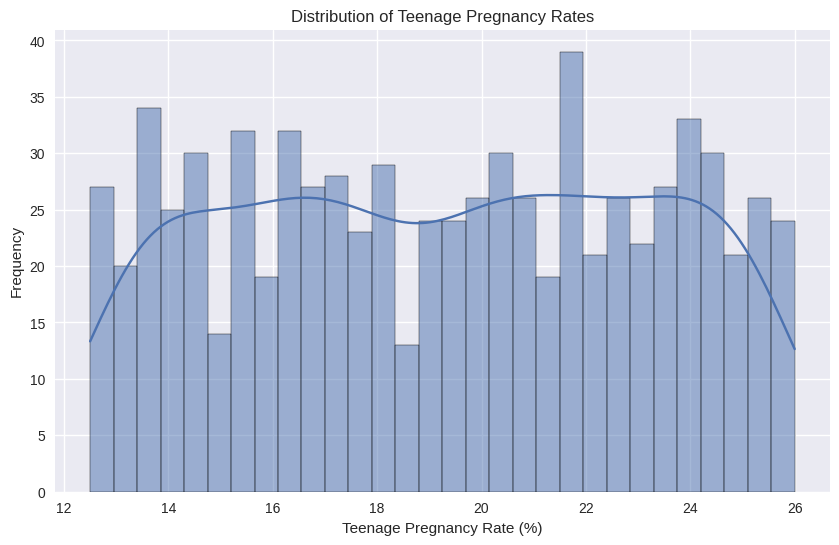

In [3]:
# Plot distribution of Teenage Pregnancy Rate
plt.figure(figsize=(10, 6))
sns.histplot(data['TeenPregnancyRate'], bins=30, kde=True)
plt.title('Distribution of Teenage Pregnancy Rates')
plt.xlabel('Teenage Pregnancy Rate (%)')
plt.ylabel('Frequency')
plt.show()

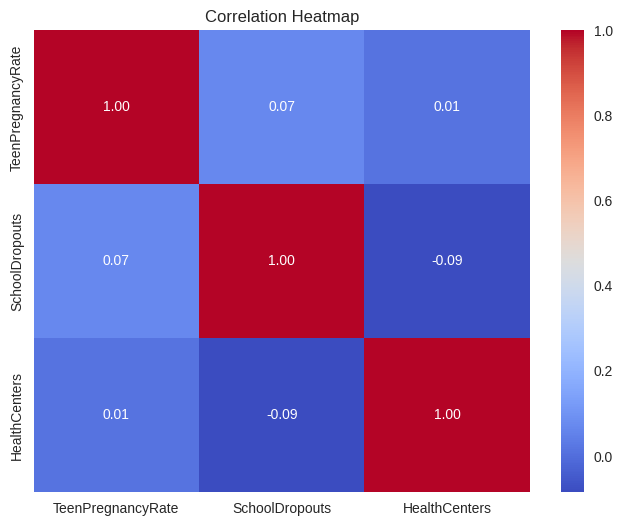

In [4]:
# Select numerical columns for correlation
numerical_cols = ['TeenPregnancyRate', 'SchoolDropouts', 'HealthCenters']
corr_matrix = data[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

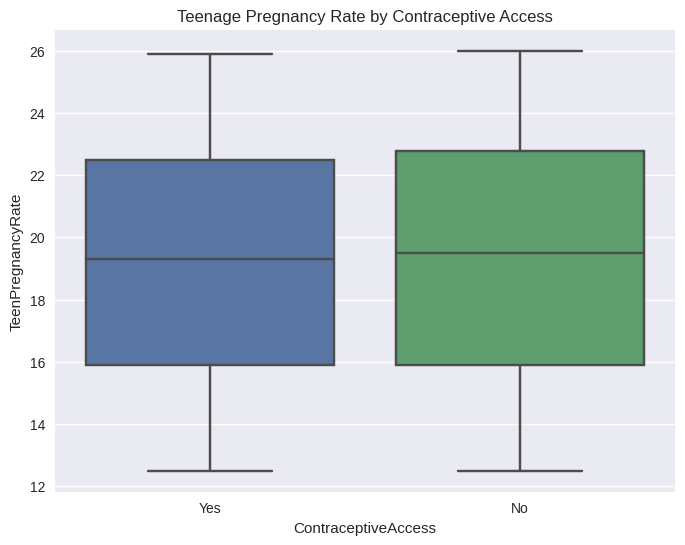

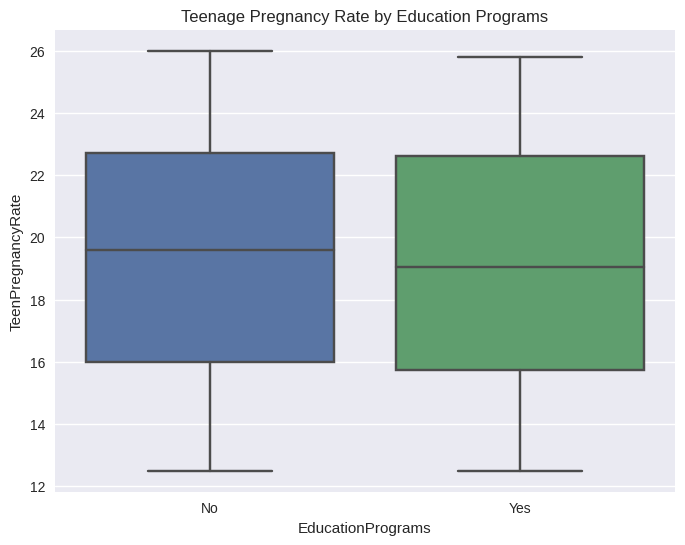

In [5]:
# Boxplot for ContraceptiveAccess vs TeenPregnancyRate
plt.figure(figsize=(8, 6))
sns.boxplot(x='ContraceptiveAccess', y='TeenPregnancyRate', data=data)
plt.title('Teenage Pregnancy Rate by Contraceptive Access')
plt.show()

# Boxplot for EducationPrograms vs TeenPregnancyRate
plt.figure(figsize=(8, 6))
sns.boxplot(x='EducationPrograms', y='TeenPregnancyRate', data=data)
plt.title('Teenage Pregnancy Rate by Education Programs')
plt.show()

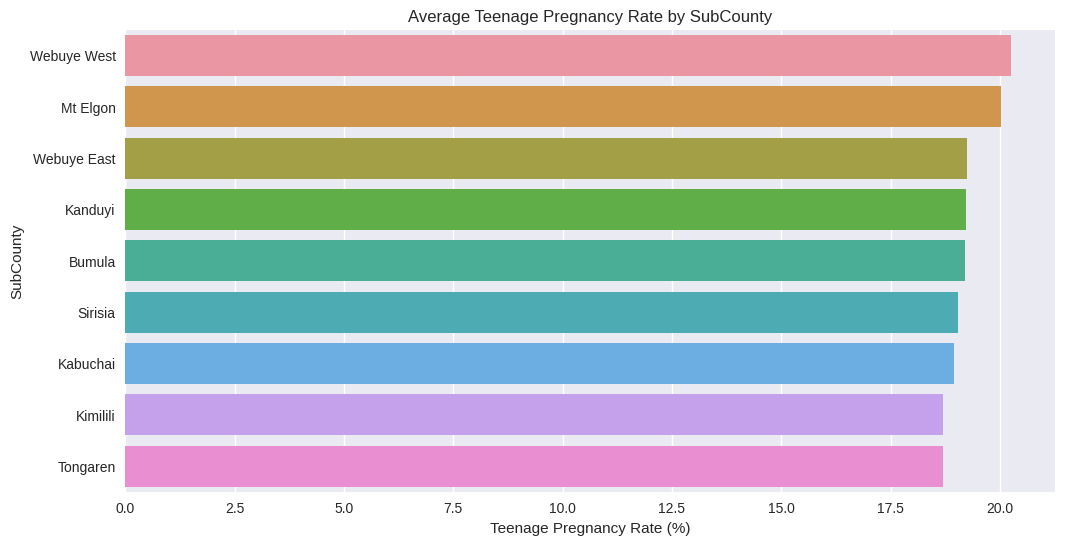

In [6]:
# Average TeenPregnancyRate by SubCounty
subcounty_rates = data.groupby('SubCounty')['TeenPregnancyRate'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=subcounty_rates.values, y=subcounty_rates.index)
plt.title('Average Teenage Pregnancy Rate by SubCounty')
plt.xlabel('Teenage Pregnancy Rate (%)')
plt.ylabel('SubCounty')
plt.show()

In [7]:
# Encode categorical columns
le = LabelEncoder()
data['ContraceptiveAccess'] = le.fit_transform(data['ContraceptiveAccess'])  # Yes=1, No=0
data['EducationPrograms'] = le.fit_transform(data['EducationPrograms'])  # Yes=1, No=0

# Encode SubCounty, Ward, Village (optional, depending on model)
# For simplicity, we'll drop these for now, but you can use one-hot encoding if needed
data_processed = data.drop(['SubCounty', 'Ward', 'Village'], axis=1)

In [8]:
# Define features (X) and target (y)
X = data_processed.drop('TeenPregnancyRate', axis=1)
y = data_processed['TeenPregnancyRate']

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

Mean Squared Error: 17.34
R² Score: -0.09


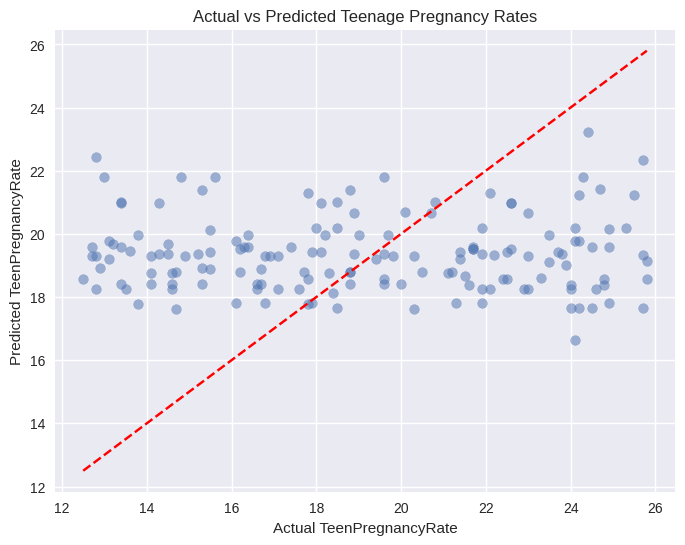

In [12]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual TeenPregnancyRate')
plt.ylabel('Predicted TeenPregnancyRate')
plt.title('Actual vs Predicted Teenage Pregnancy Rates')
plt.show()

In [13]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Average CV R² Score: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Cross-Validation R² Scores: [-0.14850257 -0.18596276 -0.21368571 -0.07955853 -0.04311851]
Average CV R² Score: -0.13 ± 0.06


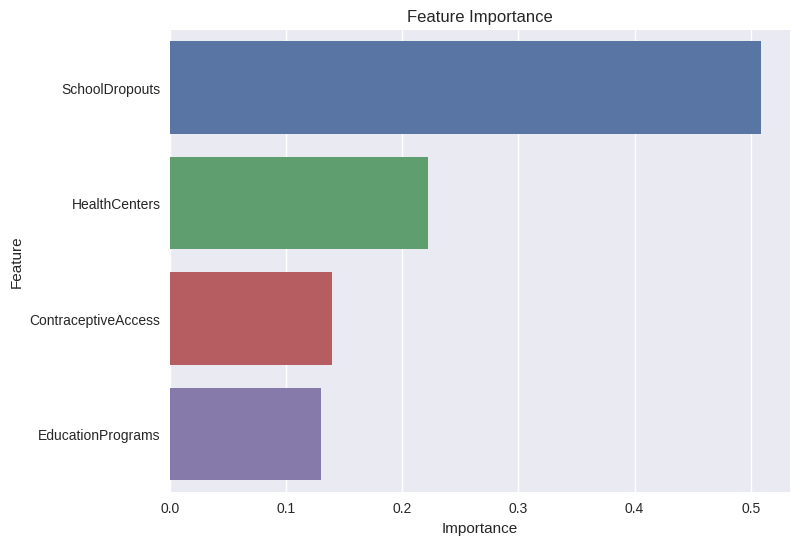

In [14]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

In [15]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearch
grid_search.fit(X_train_scaled, y_train)

# Best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R² Score: {grid_search.best_score_:.2f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print(f"Test MSE (Best Model): {mean_squared_error(y_test, y_pred_best):.2f}")
print(f"Test R² (Best Model): {r2_score(y_test, y_pred_best):.2f}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best R² Score: -0.09
Test MSE (Best Model): 16.92
Test R² (Best Model): -0.07


In [16]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
print(f"XGBoost MSE: {mean_squared_error(y_test, y_pred_xgb):.2f}")
print(f"XGBoost R²: {r2_score(y_test, y_pred_xgb):.2f}")

XGBoost MSE: 17.72
XGBoost R²: -0.12


In [17]:
data_encoded = pd.get_dummies(data, columns=['SubCounty', 'Ward'], drop_first=True)

In [18]:
import plotly.express as px
fig = px.scatter(data, x='SchoolDropouts', y='TeenPregnancyRate', color='ContraceptiveAccess')
fig.show()

# Analyzing and Predicting Teenage Pregnancy Rates in Bungoma County, 2025

## 1. Introduction
This project analyzes teenage pregnancy rates in Bungoma County, Kenya, for 2025. The dataset includes sub-county, ward, village, pregnancy rates, school dropouts, health centers, contraceptive access, and education programs. We aim to identify key factors and predict pregnancy rates using machine learning.

## 2. Data Loading and Inspection
Load the dataset and check its structure.

[Code cell: Load and inspect data]

## 3. Exploratory Data Analysis
Explore distributions, correlations, and relationships.

[Code cells: EDA plots]

**Insights**:
- Teenage pregnancy rates vary significantly by sub-county.
- Contraceptive access and education programs appear to influence rates.

## 4. Data Preprocessing
Encode categorical variables, scale features, and split data.

[Code cells: Preprocessing]

## 5. Model Building
Train a Random Forest Regressor to predict pregnancy rates.

[Code cells: Model training]

## 6. Model Evaluation
Evaluate the model using MSE, R^2, and cross-validation.

[Code cells: Evaluation]

**Results**:
- R² Score: [Insert value]
- Key predictors: [Insert features]

## 7. Hyperparameter Tuning
Optimize the model using Grid Search.

[Code cells: Tuning]

## 8. Conclusion
- **Findings**: [Summarize key insights, e.g., importance of contraceptive access]
- **Future Work**: Include more features (e.g., socioeconomic data), try other models (e.g., XGBoost).

## 9. References
- Kaggle dataset: `bungoma.csv`
- Libraries: pandas, scikit-learn, matplotlib, seaborn